#Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import warnings
warnings.filterwarnings("ignore")

#Load Dataset

In [4]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


#Dataset Information

In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


#Checking Missing Values

In [6]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


#Removing Duplicates

In [42]:
df.duplicated().sum()
df = df.drop_duplicates()

#Split Features and Target

In [9]:
x = df.drop("target", axis = 1)
y = df["target"]
print(x.shape)
print(y.shape)

(302, 13)
(302,)


#Train-Test Split

In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

#Feature Scaling

In [11]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#Train a Baseline Random Forest Model

In [12]:
rf = RandomForestClassifier(random_state = 42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest accuracy: 0.7868852459016393

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



#Confusion Matrix for Baseline Random Forest

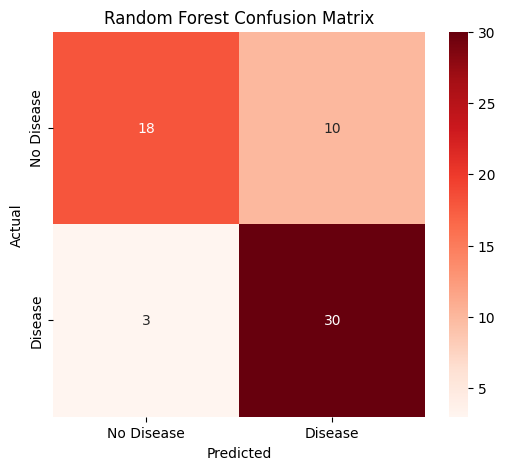

In [13]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize = (6,5))
sns.heatmap(cm,
            annot = True,
            fmt = "d",
            cmap = "Reds",
            xticklabels = ["No Disease", "Disease"],
            yticklabels = ["No Disease", "Disease"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.savefig("Random_forest_confusion_matrix")
plt.show()

#Hyperparameter Tuning

In [14]:
param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [None,5, 10, 20],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

#Run GridSearchCV

In [15]:
grid_rf = GridSearchCV(
    estimator = RandomForestClassifier(random_state = 42),
    param_grid = param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1
)
grid_rf.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

#Display Best Parameters

In [16]:
print("Best Parameters:")
print(grid_rf.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


#Cross Validation Score

In [17]:
print("best Cross validation Accuracy:")
print(grid_rf.best_score_)

best Cross validation Accuracy:
0.855017006802721


#Evaluating the Tuned Random Forest

In [18]:
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(x_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_rf))

Test Accuracy: 0.819672131147541

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.68      0.78        28
           1       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



#Confusion Matrix for Tuned Model

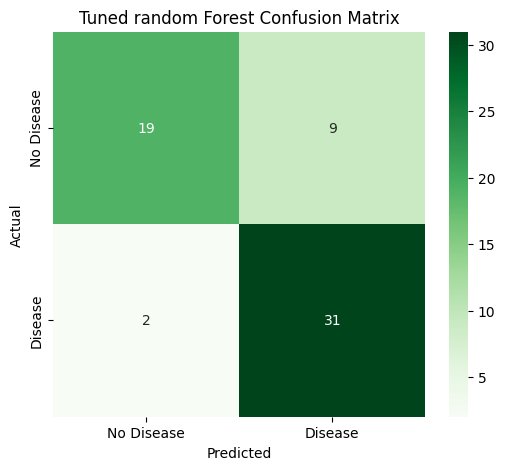

In [19]:
cm = confusion_matrix(y_test, y_pred_best_rf)
plt.figure(figsize = (6,5))
sns.heatmap(cm,
            annot = True,
            fmt = 'd',
            cmap = 'Greens',
            xticklabels = ["No Disease", "Disease"],
            yticklabels = ["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned random Forest Confusion Matrix")
plt.savefig("Tuned_random_forest_matrix")
plt.show()

#Baseline Gradient Boosting Model

In [20]:
gb = GradientBoostingClassifier(random_state =42)
gb.fit(x_train, y_train)
y_pred_gb = gb.predict(x_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.819672131147541

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.75      0.79        28
           1       0.81      0.88      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.81      0.82        61
weighted avg       0.82      0.82      0.82        61



#Confusion Matrix

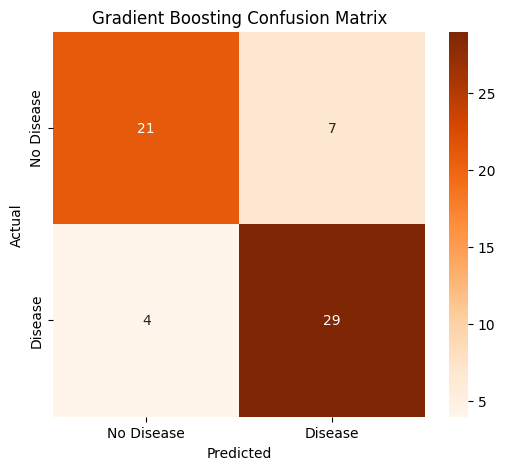

In [21]:
cm = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize = (6,5))
sns.heatmap(cm,
            annot = True,
            fmt = 'd',
            cmap = 'Oranges',
            xticklabels = ["No Disease", "Disease"],
            yticklabels = ["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")
plt.savefig("Gradient_boosting_matrix")
plt.show()

#Hyperparameter tuning using RandomizedSearchCV

In [22]:
from scipy.stats import randint, uniform
pam_dist = {
    'n_estimators': randint(50,300),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(2,8),
    'min_samples_split': randint(2,10),
    'min_samples_leaf': randint(1,5)
}

#Run RandomizedSearchCV

In [23]:
random_search = RandomizedSearchCV(
    estimator = GradientBoostingClassifier(random_state = 42),
    param_distributions = pam_dist,
    n_iter = 20,
    cv = 5,
    scoring = "accuracy",
    random_state = 42,
    n_jobs= -1
)
random_search.fit(x_train, y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f1aefc6fe60>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f1aefcc98e0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f1af05b78c0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f1aefc6ffe0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f1aefc78920>},
                   random_state=42, scoring='accuracy')

#best parameters

In [24]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'learning_rate': np.float64(0.062009396052331626), 'max_depth': 2, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 153}


#Best Cross Validation Score

In [25]:
print("best cross validation accuracy:")
print(random_search.best_score_)

best cross validation accuracy:
0.8176870748299319


#Evaluate Tuned Gradient Boosting

In [26]:
best_gb = random_search.best_estimator_
y_pred_best_gb = best_gb.predict(x_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_gb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_gb))

Test Accuracy: 0.7704918032786885

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.71      0.74        28
           1       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



#Confusion matrix

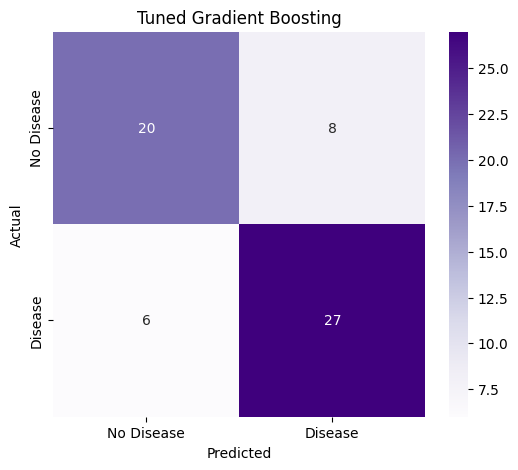

In [27]:
cm = confusion_matrix(y_test, y_pred_best_gb)
plt.figure(figsize = (6,5))
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Purples',
    xticklabels = ["No Disease", "Disease"],
    yticklabels = ["No Disease", "Disease"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Gradient Boosting")
plt.savefig("Tuned_gradient_boosting")
plt.show()

#Baseline SVM

In [28]:
svm = SVC(random_state = 42)
svm.fit(x_train_scaled, y_train)
y_pred_svm = svm.predict(x_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8360655737704918

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.71      0.80        28
           1       0.79      0.94      0.86        33

    accuracy                           0.84        61
   macro avg       0.85      0.83      0.83        61
weighted avg       0.85      0.84      0.83        61



#SVM confusion matrix

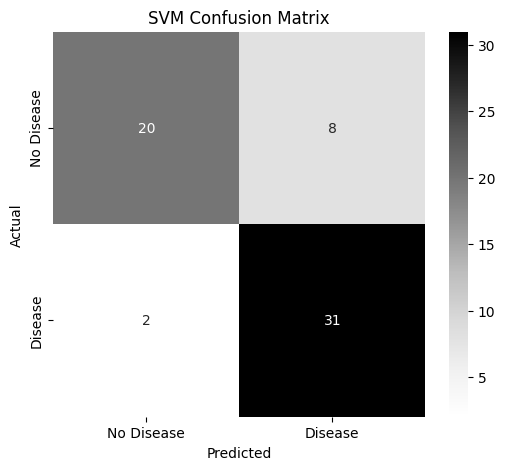

In [29]:
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot = True,
            fmt = 'd',
            cmap = 'Greys',
            xticklabels = ["No Disease", "Disease"],
            yticklabels = ["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.savefig("SVM_Matrix")
plt.show()

#Hyperparameter tuning using GridSearchCV

In [30]:
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

#Run GridSearchCV

In [31]:
grid_svm = GridSearchCV(
    estimator = SVC(),
    param_grid = param_grid_svm,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)
grid_svm.fit(x_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

#best parameters

In [32]:
print("Best Parameters:")
print(grid_svm.best_params_)

Best Parameters:
{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


#Evaluate the tuned SVM

In [33]:
best_svm = grid_svm.best_estimator_
y_pred_best_svm = best_svm.predict(x_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_svm))

Test Accuracy: 0.8032786885245902

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.64      0.75        28
           1       0.76      0.94      0.84        33

    accuracy                           0.80        61
   macro avg       0.83      0.79      0.79        61
weighted avg       0.82      0.80      0.80        61



#Tuned SVM confusion matrix

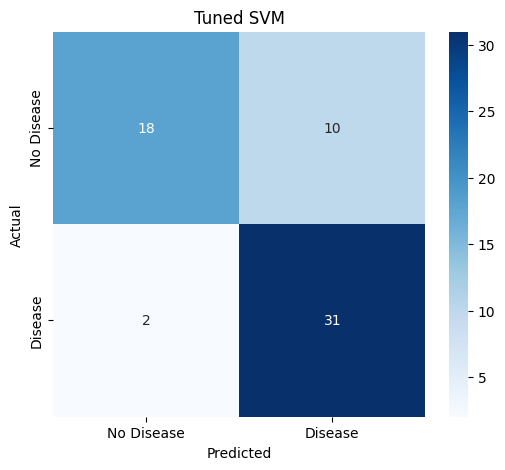

In [34]:
cm = confusion_matrix(y_test, y_pred_best_svm)
plt.figure(figsize = (6,5))
sns.heatmap(cm,
            annot = True,
            fmt = 'd',
            cmap = 'Blues',
            xticklabels = ["No Disease", "Disease"],
            yticklabels = ["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned SVM")
plt.savefig("Tuned_svm")
plt.show()

#Compare all the tuned model

In [35]:
results = pd.DataFrame({
    'Model': ['Random Forest',
              'Gradient Boosting',
              'Support Vector Machine'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_best_rf),
        accuracy_score(y_test, y_pred_best_gb),
        accuracy_score(y_test, y_pred_best_svm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_best_rf),
        precision_score(y_test, y_pred_best_gb),
        precision_score(y_test, y_pred_best_svm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_best_rf),
        recall_score(y_test, y_pred_best_gb),
        recall_score(y_test, y_pred_best_svm)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_best_rf),
        f1_score(y_test, y_pred_best_gb),
        f1_score(y_test, y_pred_best_svm)
    ]
})

#Sort the results

In [36]:
results = results.sort_values(by = 'Accuracy', ascending = False)

#Save Comparison Table

In [37]:
results.to_csv("model_comparison.csv", index = False)
print("comparison table saved successfully!")

comparison table saved successfully!


#Select the best model

In [38]:
best_model_name = results.iloc[0]["Model"]
print("Best Model is:", best_model_name)

Best Model is: Random Forest


#Save the best model

In [39]:
if best_model_name == "Random Forest":
  best_model = best_rf

In [40]:
import joblib
joblib.dump(best_model, "best_model.pkl")
print("model saved successfully!")

model saved successfully!


#Load the saved model

In [41]:
loaded_model = joblib.load("best_model.pkl")
prediction = loaded_model.predict(x_test[:5])
print(prediction)

[0 0 0 1 1]


# Conclusion

In this project, three machine learning algorithms were trained and optimized for heart disease prediction.

- Random Forest was tuned using GridSearchCV.
- Gradient Boosting was tuned using RandomizedSearchCV.
- Support Vector Machine was tuned using GridSearchCV.

The performance of all models was compared using Accuracy, Precision, Recall, and F1-score.

The best-performing model was selected based on these evaluation metrics and saved for future use.